In [ ]:
#This NOTEBOOK displays a XGBoost Model

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [106]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
#training the model(XGBoost) and checking the accuracy.

In [107]:
df = pd.read_csv("Bank_Churn.csv")

In [108]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [110]:
df = df.drop(columns="Surname")
df.drop('CustomerId', axis=1, inplace=True)

In [111]:
#one hot encoding
obj_cols = df.select_dtypes(include=['object']).columns
encoded_df = pd.get_dummies(df, columns=obj_cols)
#doing mapping
bool_cols = encoded_df.select_dtypes(include=['bool']).columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

In [112]:
encoded_df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1,0,0,1


In [113]:
X = encoded_df.drop(columns="Exited")
y = encoded_df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [114]:
#XGBoost model
#Using precision recall curve (aucpr as evaluation metrics)
clf_xgb = xgb.XGBClassifier(objective='binary:logistic',
                            seed=42,
                            eval_metric='aucpr',
                            early_stopping_rounds=10)
clf_xgb.fit(X_train,
            y_train,
            verbose=True,
            eval_set=[(X_test,y_test)])

[0]	validation_0-aucpr:0.67877
[1]	validation_0-aucpr:0.69908
[2]	validation_0-aucpr:0.70728
[3]	validation_0-aucpr:0.70974
[4]	validation_0-aucpr:0.71273
[5]	validation_0-aucpr:0.71506
[6]	validation_0-aucpr:0.71805
[7]	validation_0-aucpr:0.71669
[8]	validation_0-aucpr:0.71895
[9]	validation_0-aucpr:0.71845
[10]	validation_0-aucpr:0.71892
[11]	validation_0-aucpr:0.71906
[12]	validation_0-aucpr:0.71656
[13]	validation_0-aucpr:0.71763
[14]	validation_0-aucpr:0.71744
[15]	validation_0-aucpr:0.71696
[16]	validation_0-aucpr:0.71794
[17]	validation_0-aucpr:0.71764
[18]	validation_0-aucpr:0.71699
[19]	validation_0-aucpr:0.71705
[20]	validation_0-aucpr:0.71742
[21]	validation_0-aucpr:0.71761


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

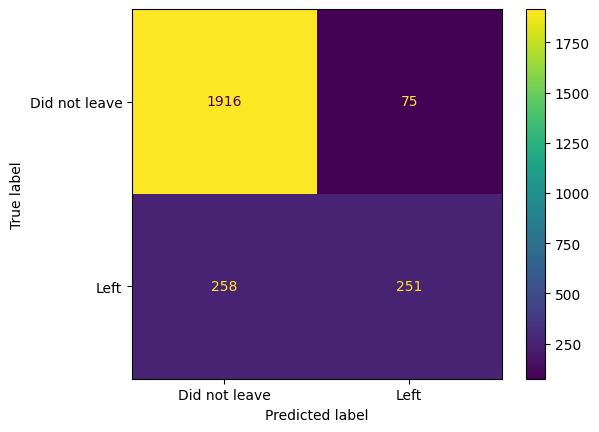

In [123]:
#CONFUSION MATRIX
y_pred = clf_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Did not leave", "Left"]
                       ).plot(values_format='d')

In [124]:
accuracy = (accuracy_score(y_test,y_pred))*100
auc_roc_sc = roc_auc_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC ROC Score: {auc_roc_sc:.4f}")

Accuracy: 86.6800
AUC ROC Score: 0.7277


In [116]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [25,100,175],
    "max_depth": [3,4,5],
    "learning_rate": [0.1,0.01,0.05],
    "gamma": [0,0.25,1.0],
    "reg_lambda": [0,1.0,10.0],
    "scale_pos_weight": [1,2,4]
}
optimal_params = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic',
                                seed=42,
                                subsample=0.9,
                                colsample_bytree=0.5,
                                eval_metric="auc",
                                early_stopping_rounds=10),
    param_grid=param_grid,
    scoring='roc_auc',
    verbose=0,
    n_jobs=10,
    cv=3
)
optimal_params.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=False)
print(optimal_params.best_params_)

{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_lambda': 0, 'scale_pos_weight': 4}


In [117]:
param_grid_2 = {
    "n_estimators":[100,150,175],
    "reg_lambda": [0,0.25,0.5],
    "gamma": [0.25,0.5,0.75],
    "scale_pos_weight": [3.9,4.5,5.2],
    "learning_rate": [0.1,0.15,0.175],
}
optimal_params2 = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic',
                                seed=42,
                                subsample=0.9,
                                colsample_bytree=0.5,
                                eval_metric="auc",
                                early_stopping_rounds=10),
    param_grid=param_grid_2,
    scoring='roc_auc',
    verbose=0,
    n_jobs=10,
    cv=3
)
optimal_params2.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=False)
print(optimal_params2.best_params_)

{'gamma': 0.5, 'learning_rate': 0.1, 'n_estimators': 100, 'reg_lambda': 0.5, 'scale_pos_weight': 3.9}


Scale_Pos_Weight = 3.9
Gamma = 0.5
Reg_Lambda = 0.5
Max_depth = 4
Learning_rate = 0.1
N_estimators = 100

In [118]:
final_clf_xgb = xgb.XGBClassifier(objective='binary:logistic',
                                  seed=42,
                                  gamma=0.5,
                                  max_depth=4,
                                  learning_rate=0.1,
                                  n_estimators=100,
                                  reg_lambda=0.5,
                                  scale_pos_weight=3.9,
                                  subsample=0.9,
                                  colsample_bytree=0.5,
                                  eval_metric='aucpr',
                                  early_stopping_rounds=10)

final_clf_xgb.fit(X_train,
                  y_train,
                  eval_set=[(X_test,y_test)],
                  verbose=True)

[0]	validation_0-aucpr:0.50484
[1]	validation_0-aucpr:0.51448
[2]	validation_0-aucpr:0.51666
[3]	validation_0-aucpr:0.48124
[4]	validation_0-aucpr:0.62860
[5]	validation_0-aucpr:0.65882
[6]	validation_0-aucpr:0.67399
[7]	validation_0-aucpr:0.68188
[8]	validation_0-aucpr:0.69411
[9]	validation_0-aucpr:0.68604
[10]	validation_0-aucpr:0.68437
[11]	validation_0-aucpr:0.69177
[12]	validation_0-aucpr:0.69354
[13]	validation_0-aucpr:0.68872
[14]	validation_0-aucpr:0.69904
[15]	validation_0-aucpr:0.69381
[16]	validation_0-aucpr:0.69508
[17]	validation_0-aucpr:0.69393
[18]	validation_0-aucpr:0.68878
[19]	validation_0-aucpr:0.68809
[20]	validation_0-aucpr:0.69868
[21]	validation_0-aucpr:0.70431
[22]	validation_0-aucpr:0.70269
[23]	validation_0-aucpr:0.70154
[24]	validation_0-aucpr:0.70118
[25]	validation_0-aucpr:0.70535
[26]	validation_0-aucpr:0.71119
[27]	validation_0-aucpr:0.71045
[28]	validation_0-aucpr:0.71440
[29]	validation_0-aucpr:0.71505
[30]	validation_0-aucpr:0.71628
[31]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [119]:
from sklearn.metrics import precision_recall_curve

y_prob = final_clf_xgb.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fscore = 2 * precision * recall / (precision + recall)
best_threshold = thresholds[np.argmax(fscore)]
best_threshold

np.float32(0.6238682)

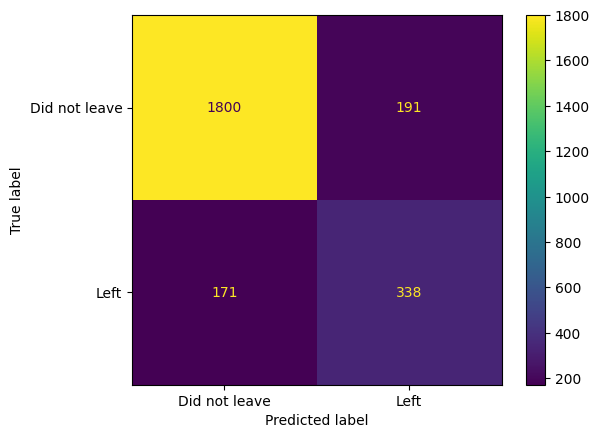

In [120]:
y_prob = final_clf_xgb.predict_proba(X_test)[:,1]
threshold = 0.624
y_pred_final = (y_prob > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Did not leave", "Left"]
                       ).plot(values_format='d')

In [122]:
from sklearn.metrics import roc_auc_score

print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

auc = roc_auc_score(y_test, y_prob)
accuracysc = (accuracy_score(y_test, y_pred_final))*100
print(f"ACCURACY: {accuracysc:.4f}")
print(f"AUC-ROC: {auc:.4f}")

              precision    recall  f1-score   support

    No Churn       0.91      0.90      0.91      1991
       Churn       0.64      0.66      0.65       509

    accuracy                           0.86      2500
   macro avg       0.78      0.78      0.78      2500
weighted avg       0.86      0.86      0.86      2500

ACCURACY: 85.5200
AUC-ROC: 0.8773
